# Import Libraries

In [ ]:
import nltk
import string
nltk.download('punkt')
from nltk.tokenize import word_tokenize
nltk.download('stopwords')
from nltk.corpus import stopwords
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.stem import WordNetLemmatizer
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier

[nltk_data] Downloading package punkt to C:\Users\LAPTOPS
[nltk_data]     HOUSE\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\LAPTOPS
[nltk_data]     HOUSE\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\LAPTOPS
[nltk_data]     HOUSE\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\LAPTOPS
[nltk_data]     HOUSE\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


# Load Data

In [ ]:
data = pd.read_csv("/content/IMDB Dataset.csv")

# Explore Data

In [4]:
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [5]:
data['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [7]:
data.isna().sum()

review       0
sentiment    0
dtype: int64

# Data Preprocessing

In [8]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text, flag):
    #convert all to lowercase
    text = text.lower()

    # remove punctuations
    text = text.translate(str.maketrans('', '', string.punctuation))

    # tokenization
    tokens = word_tokenize(text)

    final = []
    
    # remove stopwords

    for token in tokens:
        if token not in stop_words:
            final.append(token)



    # lemmatization
    lemmatized = [lemmatizer.lemmatize(token) for token in final]


    if flag == "tfidf":
        return ' '.join(lemmatized) #to use with tf idf vectorizer,
    elif flag == "w2v":
        return  lemmatized #  to use with word2vec
     

In [11]:
x = data['review'].apply(lambda x: preprocess_text(x, "tfidf"))
y = data['sentiment']

In [12]:
encoder = LabelEncoder()

y = encoder.fit_transform(y)

# Split Data

In [13]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# TF-IDF

In [14]:
tfidf_vectorizer = TfidfVectorizer()
x_train = tfidf_vectorizer.fit_transform(x_train)
x_test = tfidf_vectorizer.transform(x_test)

# Naive Bayes Training

In [15]:
model = MultinomialNB()

model.fit(x_train, y_train)
y_pred = model.predict(x_test)

# Naive Bayes Model Evaluation

In [16]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.89      0.87      4961
           1       0.88      0.85      0.87      5039

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



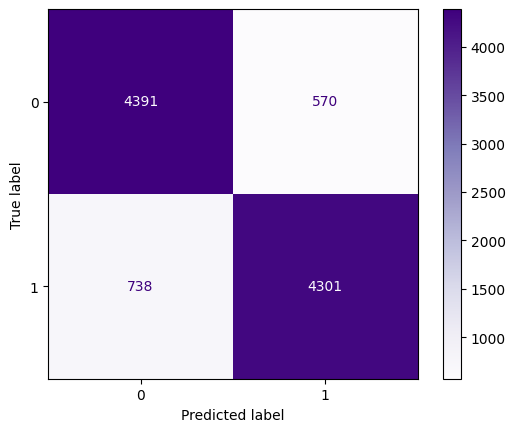

In [18]:
ConfusionMatrixDisplay.from_estimator(
    model,
    x_test,
    y_test,
    cmap=plt.cm.Purples
)
plt.show()

# SVM Model Training

In [ ]:
svm = SVC(kernel='linear', random_state=42)

svm.fit(x_train, y_train)
y_pred_svm = svm.predict(x_test)


# SVM Model Evaluation

In [ ]:
acc_svm = accuracy_score(y_test, y_pred_svm)
print("=====================================================")

print(classification_report(y_test, y_pred_svm))

In [ ]:
ConfusionMatrixDisplay.from_estimator(
    svm,
    x_test,
    y_test,
    cmap=plt.cm.Purples
)

# LightGBM Boosting Training

In [ ]:
lgbm = LGBMClassifier(random_state=42)

lgbm.fit(x_train, y_train)
y_pred_lgbm = lgbm.predict(x_test)

# Gradient Boosting Evaluation

In [ ]:
acc_lgbm = accuracy_score(y_test, y_pred_lgbm)
print("=====================================================")
print(classification_report(y_test, y_pred_lgbm))


In [ ]:
ConfusionMatrixDisplay.from_estimator(
    lgbm,
    x_test,
    y_test,
    cmap=plt.cm.Purples
)   